In [1]:
pip install opencv-python numpy

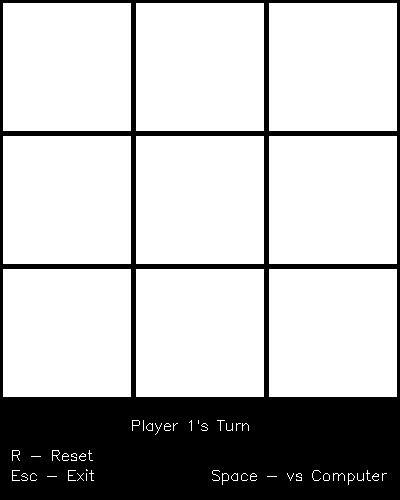

Player 1's turn (simulating a random move)
Simulating human move at (0, 1)


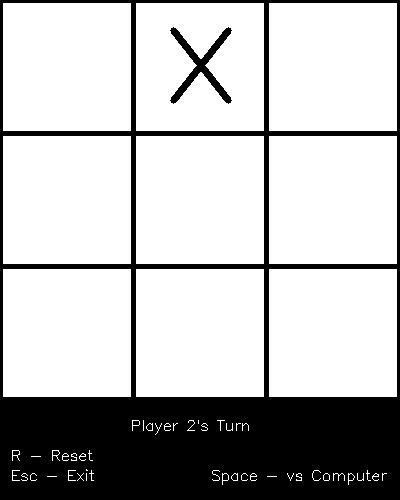

Player 2's turn (simulating a random move)
Simulating human move at (1, 1)


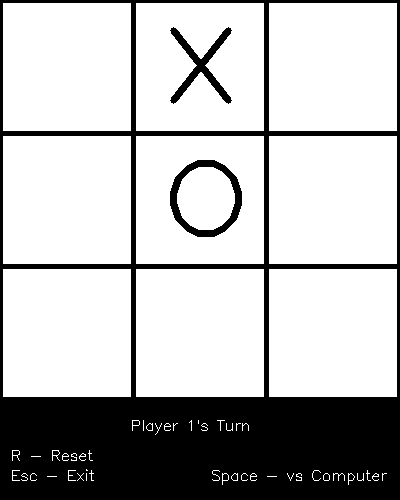

Player 1's turn (simulating a random move)
Simulating human move at (2, 2)


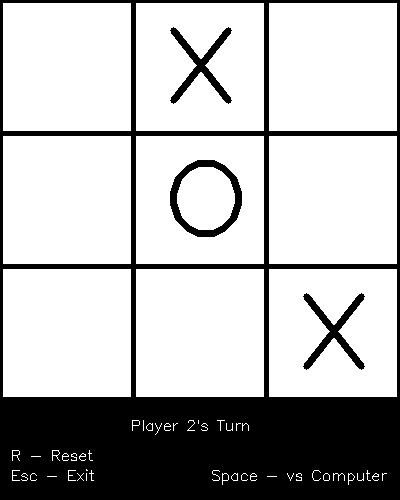

Player 2's turn (simulating a random move)
Simulating human move at (2, 1)


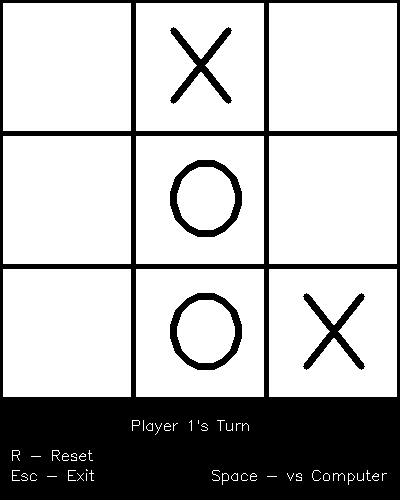

Player 1's turn (simulating a random move)
Simulating human move at (1, 2)


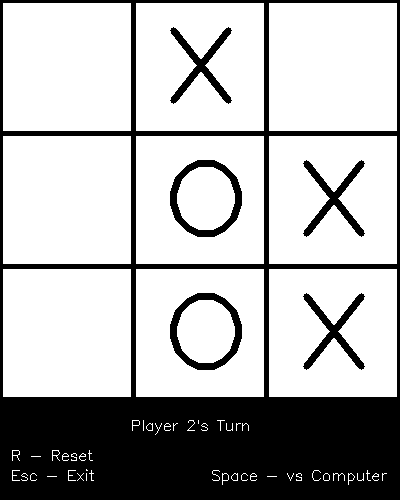

Player 2's turn (simulating a random move)
Simulating human move at (2, 0)


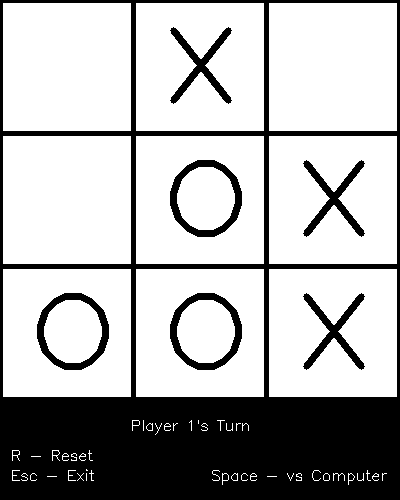

Player 1's turn (simulating a random move)
Simulating human move at (1, 0)


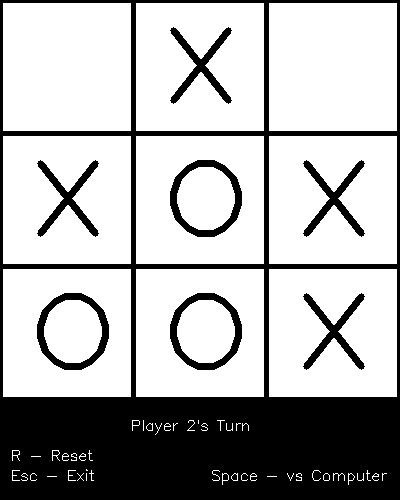

Player 2's turn (simulating a random move)
Simulating human move at (0, 0)


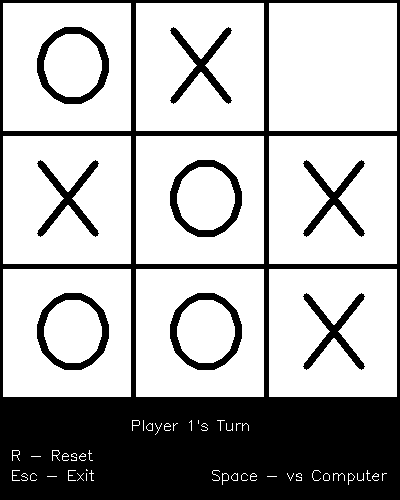

Player 1's turn (simulating a random move)
Simulating human move at (0, 2)


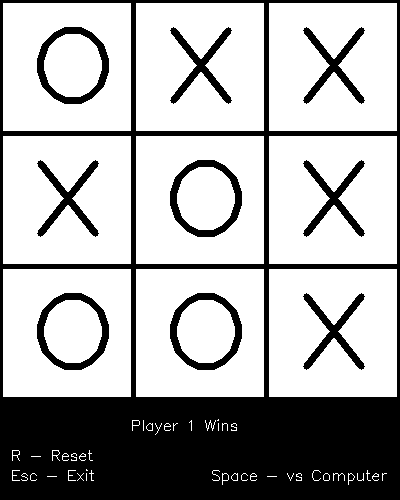

Game Over!


In [1]:
import cv2
import numpy as np
from random import randint
import time
from google.colab.patches import cv2_imshow


# -----------------------------------------------------------------------------------

# Classes
class Block():
    def __init__(self, i, j):
        self.value = None
        self.pos = (i, j)

    def setValue(self, value):
        self.value = value


# -----------------------------------------------------------------------------------

class GUI():
    def __init__(self, windowName):
        self.windowName = windowName
        self.width, self.height = 400, 400
        self.menuHeight = 100
        self.image = np.zeros((self.height + self.menuHeight, self.width, 3), np.uint8)
        self.turn = 1
        self.vsCom = 0
        self.reset()

    # -----------------------------------------------------------------------------------
    # Reset Game
    def reset(self):
        self.blocks = []
        self.win = False
        self.change = True
        self.selected = False
        for i in range(3):
            row = []
            for j in range(3):
                row.append([Block(i, j), (j * (self.width // 3) + 3, i * (self.height // 3) + 3),
                            ((j + 1) * (self.width // 3) - 3, (i + 1) * (self.height // 3) - 3)])
            self.blocks.append(row)

    # -----------------------------------------------------------------------------------
    # Drawing GUI and Game Screen
    def draw(self):
        self.image = np.zeros((self.height + self.menuHeight, self.width, 3), np.uint8)
        for i in range(3):
            for j in range(3):
                start_point = self.blocks[i][j][1]
                end_point = self.blocks[i][j][2]
                cv2.rectangle(self.image, start_point, end_point, (255, 255, 255), -1)
                value = " " if self.blocks[i][j][0].value is None else self.blocks[i][j][0].value
                cv2.putText(self.image, value, (j * (self.width // 3) + 25, (i * self.height // 3) + 100),
                            cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 0), 5)
        if self.checkWin():
            string = ("Player " + str(
                self.turn) + " Wins" if self.turn != self.vsCom else "Computer Wins") if self.turn == 1 else (
                "Player " + str(2) + " Win" if self.turn != self.vsCom else "Computer Win")
        else:
            if not self.checkDraw():
                string = ("Player " + str(
                    self.turn) + "'s Turn" if self.turn != self.vsCom else "Computer's Turn") if self.turn == 1 else (
                    "Player " + str(2) + "'s Turn" if self.turn != self.vsCom else "Computer's Turn")
            else:
                string = "Match Draw!!"
        cv2.putText(self.image, string, (self.width // 2 - 70, self.height + 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255, 255, 255), 1)
        cv2.putText(self.image, "R - Reset", (10, self.height + 60), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(self.image, "Esc - Exit", (10, self.height + 80), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        string = "vs Computer" if self.vsCom == 0 else "vs Human"
        cv2.putText(self.image, "Space - " + string, (self.width // 2 + 10, self.height + 80), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (255, 255, 255), 1)

        if self.selected and not (self.checkWin() or self.checkDraw()):
            self.change = True
            self.selected = False
            self.turn *= -1

    # -----------------------------------------------------------------------------------
    # Game Play Functions
    def mainLoop(self):  # Game Loop modified for Colab non-interactive display
        # In Colab, cv2.namedWindow and cv2.setMouseCallback do not provide interactive GUI.
        # cv2.waitKey also doesn't capture real-time input.
        # This modification aims to display the game states as images.
        try:
            # The loop will proceed until the game is won or drawn.
            while True:
                # Always draw the current state
                self.draw()
                cv2_imshow(self.image)
                time.sleep(1) # Add a delay to observe changes

                # Check if game is over after drawing and displaying
                if self.checkWin() or self.checkDraw():
                    print("Game Over!")
                    break # Exit loop if game has ended

                # Computer's turn logic
                if self.vsCom == self.turn:
                    print(f"Computer's turn (Player {'1' if self.turn == 1 else '2'})")
                    block = self.nextMove()
                    if block:
                        block.setValue("x" if self.turn == 1 else "o")
                        self.selected = True
                        self.change = True
                    else:
                        print("Computer could not make a move (unexpected, board might be full).")
                        break

                # Human player's turn logic (simulated in Colab)
                else:
                    print(f"Player {'1' if self.turn == 1 else '2'}'s turn (simulating a random move)")
                    # Simulate a random move for the human player to allow the game to progress.
                    empty_blocks = []
                    for r in range(3):
                        for c in range(3):
                            if self.blocks[r][c][0].value is None:
                                empty_blocks.append(self.blocks[r][c][0])

                    if empty_blocks:
                        chosen_block = empty_blocks[randint(0, len(empty_blocks) - 1)]
                        chosen_block.setValue("x" if self.turn == 1 else "o")
                        self.selected = True
                        self.change = True
                        print(f"Simulating human move at {chosen_block.pos}")
                    else:
                        print("No empty blocks for simulated human move.")
                        break

                # After a move, switch turn if a move was selected and game not over
                if self.selected and not (self.checkWin() or self.checkDraw()):
                    self.change = True
                    self.selected = False
                    self.turn *= -1

        except Exception as e:
            print(f"An error occurred during game execution: {e}")

    def checkWin(self):
        self.win = False
        if (self.blocks[0][0][0].value is not None and self.blocks[0][0][0].value == self.blocks[0][1][0].value ==
            self.blocks[0][2][0].value) or (
                self.blocks[1][0][0].value is not None and self.blocks[1][0][0].value == self.blocks[1][1][0].value ==
                self.blocks[1][2][0].value) or (
                self.blocks[2][0][0].value is not None and self.blocks[2][0][0].value == self.blocks[2][1][0].value ==
                self.blocks[2][2][0].value) or (
                self.blocks[0][0][0].value is not None and self.blocks[0][0][0].value == self.blocks[1][0][0].value ==
                self.blocks[2][0][0].value) or (
                self.blocks[0][1][0].value is not None and self.blocks[0][1][0].value == self.blocks[1][1][0].value ==
                self.blocks[2][1][0].value) or (
                self.blocks[0][2][0].value is not None and self.blocks[0][2][0].value == self.blocks[1][2][0].value ==
                self.blocks[2][2][0].value) or (
                self.blocks[0][0][0].value is not None and self.blocks[0][0][0].value == self.blocks[1][1][0].value ==
                self.blocks[2][2][0].value) or (
                self.blocks[2][0][0].value is not None and self.blocks[2][0][0].value == self.blocks[0][2][0].value ==
                self.blocks[1][1][0].value):
            self.win = True
        return self.win

    def checkDraw(self):
        flag = True
        for i in range(3):
            for j in range(3):
                if self.blocks[i][j][0].value == None:
                    flag = False
        return flag

    # -----------------------------------------------------------------------------------
    # Computers Move Decided Using Minmax Algorithm
    def nextMove(self):  # Decide NextMove of Computer by this return the block to selected by the Computer
        flag = 0
        blocks = []
        for i in range(3):
            for j in range(3):
                if self.blocks[i][j][0].value == None:
                    blocks.append(self.blocks[i][j][0])
        if not (len(blocks) == sum([len(row) for row in self.blocks]) or len(blocks) == sum(
                [len(row) for row in self.blocks]) - 1 or len(blocks) == 1):
            scoresList = {}
            for block in blocks:
                if block.value == None:
                    if self.computerWins(block):
                        scoresList[block] = 50
                    elif self.playerWins(block):
                        scoresList[block] = -50
                    elif not self.checkDraw():
                        block.value = ("x" if self.turn == 1 else "o")
                        scoresList[block] = self.min_max(1, self.vsCom)
                        block.value = None
                    else:
                        scoresList[block] = 0
            # Choosing Either Best Closest Winning Score or Next Closest Losing Score
            bestScore = (
                min(scoresList.values()) if abs(min(scoresList.values())) > abs(max(scoresList.values())) else max(
                    scoresList.values()))
            blocks = []
            for block in scoresList:
                if scoresList[block] == bestScore:
                    ##print(block.pos,bestScore)
                    blocks.append(block)
        choice = blocks[randint(0, len(blocks) - 1)]
        # print(choice.pos)
        return choice

    def min_max(self, depth, player):  # MinMax Algorithms Function
        scoresList = []
        for row in self.blocks:
            for block in row:
                if block[0].value == None:
                    if self.computerWins(block[0]):
                        return (50 - depth)
                    elif self.playerWins(block[0]):
                        return (-50 + depth)
                    else:
                        block[0].value = ("x" if self.turn == 1 else "o")
                        scoresList.append(self.min_max(depth + 1, player * -1))
                        block[0].value = None
        if scoresList:
            return (min(scoresList) if abs(min(scoresList)) > abs(max(scoresList)) else max(scoresList))
        return 0

    def computerWins(self, block):
        flag = False
        block.value = ("x" if self.vsCom == 1 else "o")
        if self.checkWin(): flag = True
        self.win = False
        block.value = None
        return flag

    def playerWins(self, block):
        flag = False
        block.value = ("x" if self.vsCom != 1 else "o")
        if self.checkWin(): flag = True
        self.win = False
        block.value = None
        return flag

    # -----------------------------------------------------------------------------------
    # Mouse Click Functions - (For User Players)
    def mouseCall(self, event, posx, posy, flag, param):
        # Mouse callbacks are not supported in Colab's cv2_imshow display.
        pass

    def setBlockInPos(self, x, y):
        # This function would be called by mouseClick, but mouse clicks are not supported.
        pass


# -----------------------------------------------------------------------------------

# Main Program
game = GUI("TicTacToe")
game.mainLoop()